In [2]:
print("Hello")

Hello


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os
from scipy.signal import resample_poly

Add the Step logger miliseconds in the data as another column in the trimmed data

In [7]:
Data_Dir = Path(r"C:\Users\Vaibhav\OneDrive - CNR\FILIPPO PALUMBO's files - IPIN2026\StepLogger")
session_files = ["20260903T103016_davide2", "20260903T104431_davide3", "20260903T111311_Filippo01", "20260903T113135_Filippo02", "20260903T120425_eqbal1", "20260903T122244_eqbal3"]
prefix_file = "buttonsPressed"

output_file = [os.path.join("Subject_1_D", "Session_1"), os.path.join("Subject_1_D", "Session_2"), os.path.join("Subject_2_F", "Session_1"), os.path.join("Subject_2_F", "Session_2"), os.path.join("Subject_3_I", "Session_1"), os.path.join("Subject_3_I", "Session_2")]
Data_Doc_Dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")

for i in range(len(session_files)):
    file_path = os.path.join(Data_Dir, session_files[i],f"{prefix_file}.log")
    step_logger_df = pd.read_csv(file_path, delimiter = ":", header = None, names = ["time", "Checkpoint", "zeros_1", "zeros_2", "zeros_3"])
    step_logger_df["time_s"] = step_logger_df["time"] / 1000  # Convert milliseconds to seconds
    step_logger_df["time_s"] = (step_logger_df["time_s"] - step_logger_df["time_s"].iloc[0]).round(4)
    
    OUT_DIR = Path(os.path.join(Data_Doc_Dir, output_file[i], "step_logger"))
    OUT_DIR.mkdir(exist_ok=True)

    step_logger_df.to_csv(OUT_DIR / f"buttonsPressed.csv", index=False)

    print(f"Saved {len(step_logger_df)} rows to {OUT_DIR}")

Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\step_logger
Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_2\step_logger
Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_1\step_logger
Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_2\step_logger
Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_1\step_logger
Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_2\step_logger


Exploring the Step logger recordings

The length of the df 79046


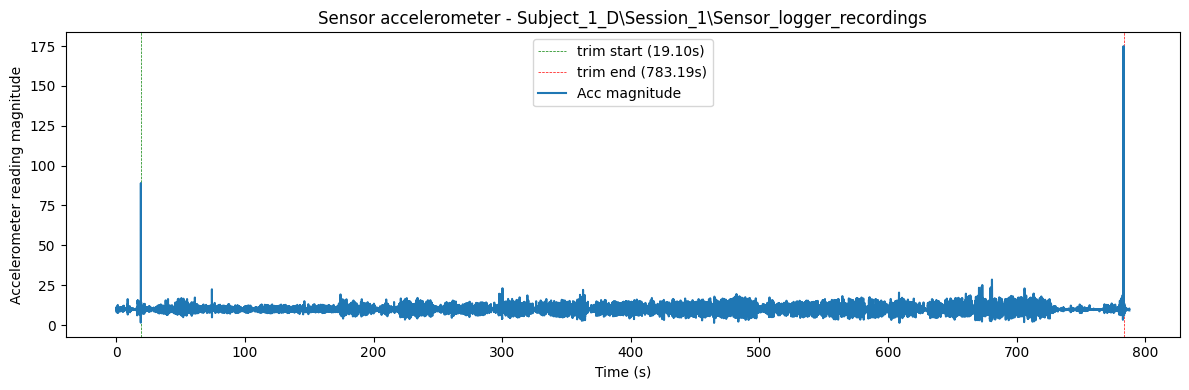

The length of the df 79310


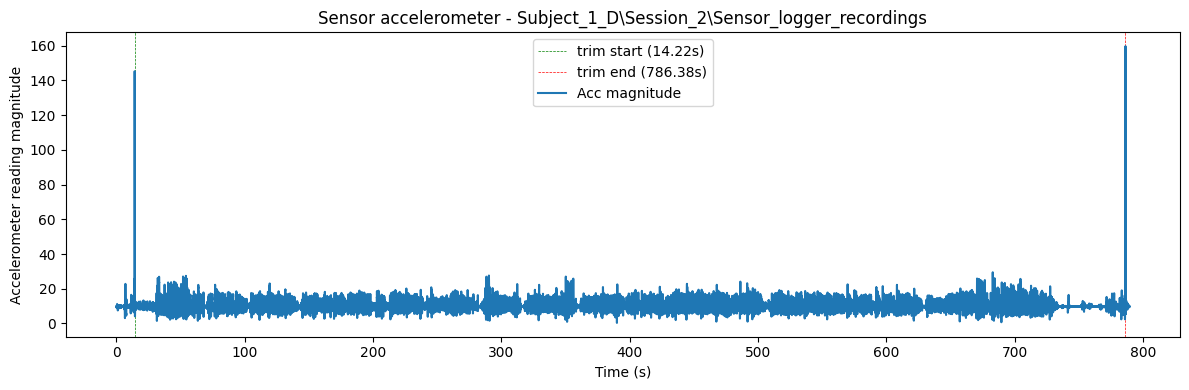

The length of the df 85625


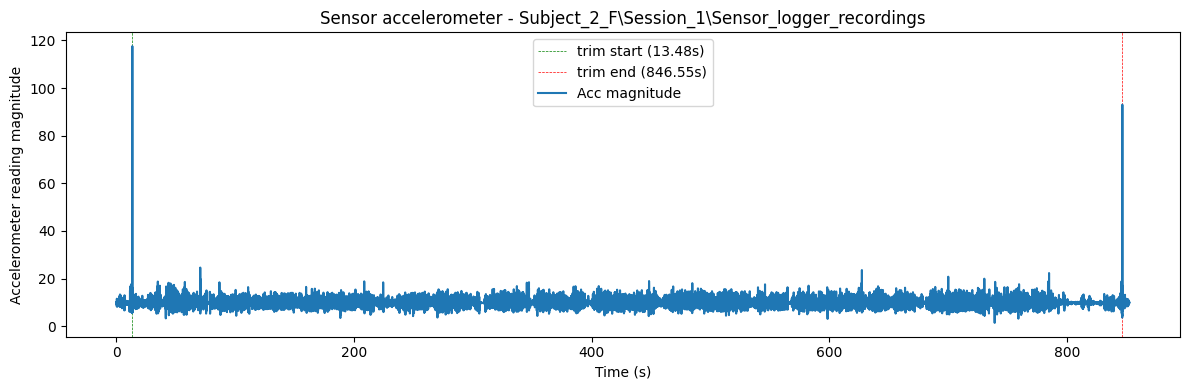

The length of the df 84703


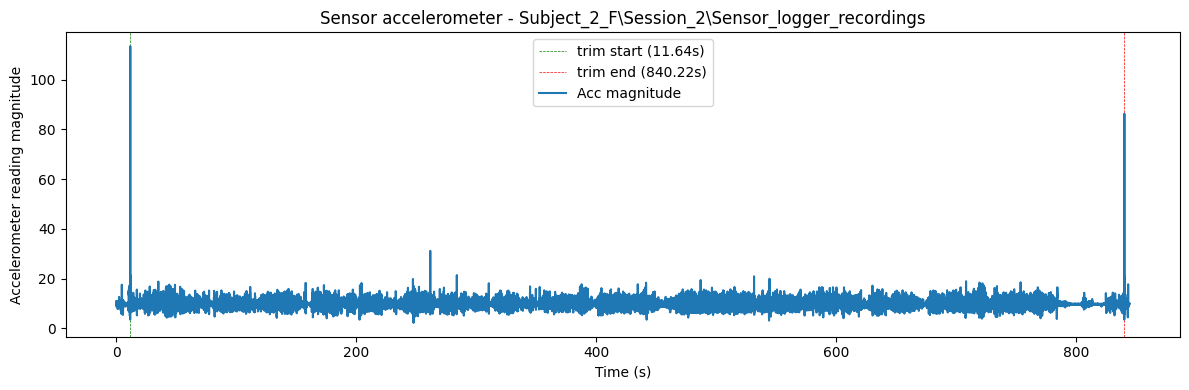

The length of the df 86530


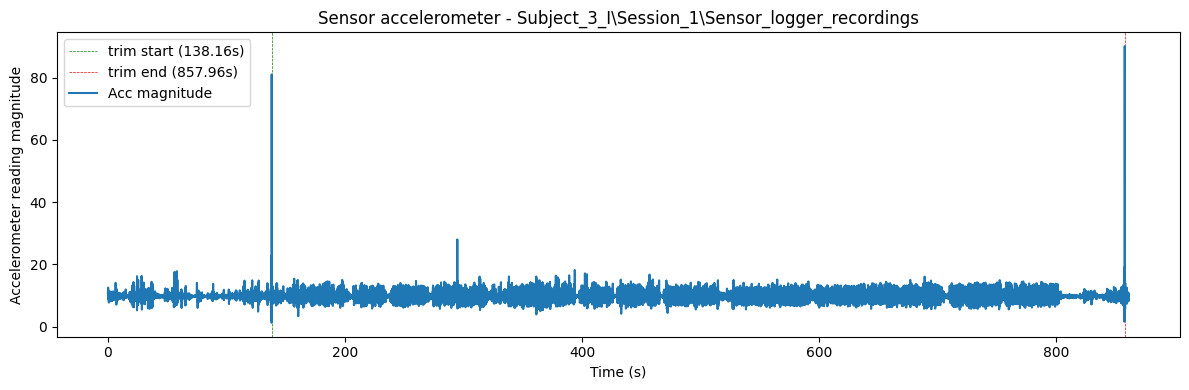

The length of the df 75668


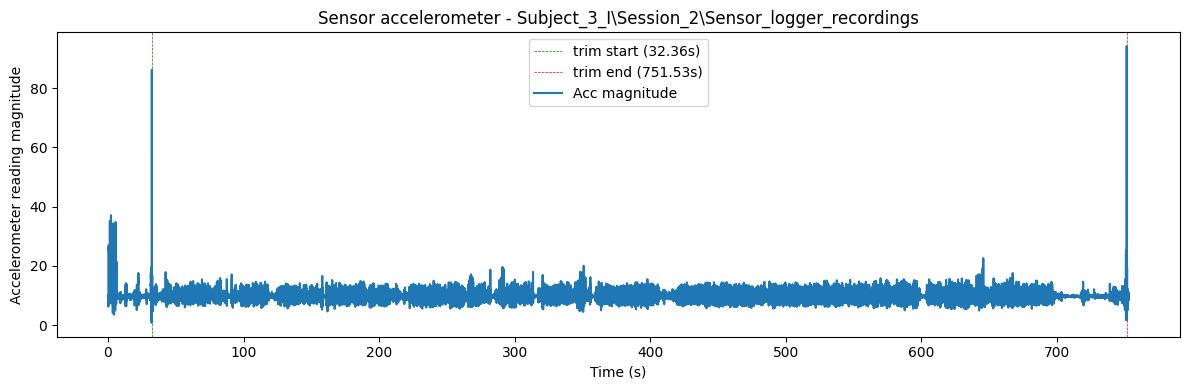

In [25]:
dir_file = [os.path.join("Subject_1_D", "Session_1", "Sensor_logger_recordings"), os.path.join("Subject_1_D", "Session_2", "Sensor_logger_recordings"), os.path.join("Subject_2_F", "Session_1", "Sensor_logger_recordings"), os.path.join("Subject_2_F", "Session_2", "Sensor_logger_recordings"), os.path.join("Subject_3_I", "Session_1", "Sensor_logger_recordings"), os.path.join("Subject_3_I", "Session_2", "Sensor_logger_recordings")]
data_doc_dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")
file_prefix = "TotalAcceleration.csv"

def trim_signal(df: pd.DataFrame, t_start: float, t_end: float) -> pd.DataFrame:
    mask = (df["Time_s"] >= t_start) & (df["Time_s"] <= t_end)
    return df.loc[mask].reset_index(drop=True)

def plot_acceleration_magnitude(dir_file, data_doc_dir, file_prefix):
    for i in range(len(dir_file)):
        
        file_path = os.path.join(data_doc_dir, dir_file[i], file_prefix)
        df = pd.read_csv(file_path, delimiter=',', header=0)
        print(f"The length of the df", len(df))
        df["time_s"] = df["time"] / 1e9
        df["time_s"] = (df["time_s"] - df["time_s"].iloc[0]).round(4)
        time_start, time_end = get_start_end_time(df)
        acc_mag = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)

        plt.figure(figsize=(12, 4))
        plt.ticklabel_format(useOffset=False, style="plain")
        plt.axvline(time_start, color="green", linestyle="--", linewidth=0.5, label=f"trim start ({time_start:.2f}s)")
        plt.axvline(time_end, color="red", linestyle="--", linewidth=0.5, label=f"trim end ({time_end:.2f}s)")
        plt.plot(df["time_s"], acc_mag, label="Acc magnitude")
        plt.xlabel("Time (s)")
        plt.ylabel("Accelerometer reading magnitude")
        plt.title(f"Sensor accelerometer - {dir_file[i]}")
        plt.legend()
        plt.tight_layout()
        plt.show()

def get_start_end_time(df: pd.DataFrame) -> tuple[float, float]:
    # find two values in which acc_mag is higest [1st and second peak ]
    # Since we want to find from start and finish of the signal, we can look only in 150 seconds from start and end time
    time_start = df["time_s"].iloc[0]
    time_end = df["time_s"].iloc[-1]
    highest_acc_mag = 0
    for i in range(20000):  # 10000 samples approx 120 seconds 
        acc_mag = np.sqrt(df["x"].iloc[i]**2 + df["y"].iloc[i]**2 + df["z"].iloc[i]**2)
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            time_start = df["time_s"].iloc[i]

    highest_acc_mag = 0
    for i in range(len(df) - 20000, len(df)):
        acc_mag = np.sqrt(df["x"].iloc[i]**2 + df["y"].iloc[i]**2 + df["z"].iloc[i]**2)
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            time_end = df["time_s"].iloc[i]
    return time_start, time_end

plot_acceleration_magnitude(dir_file, data_doc_dir, file_prefix)

Trimming files in the sensor logger and saving them in a folder

In [26]:
dir_file = [os.path.join("Subject_1_D", "Session_1", "Sensor_logger_recordings"), os.path.join("Subject_1_D", "Session_2", "Sensor_logger_recordings"), os.path.join("Subject_2_F", "Session_1", "Sensor_logger_recordings"), os.path.join("Subject_2_F", "Session_2", "Sensor_logger_recordings"), os.path.join("Subject_3_I", "Session_1", "Sensor_logger_recordings"), os.path.join("Subject_3_I", "Session_2", "Sensor_logger_recordings")]
data_doc_dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")
prefix_file = "TotalAcceleration.csv"

def trim_signal(df: pd.DataFrame, t_start: float, t_end: float) -> pd.DataFrame:
    mask = (df["time_s"] >= t_start) & (df["time_s"] <= t_end)
    return df.loc[mask].reset_index(drop=True)

def get_start_end_time(df: pd.DataFrame) -> tuple[float, float]:
    # find two values in which acc_mag is higest [1st and second peak ]
    # Since we want to find from start and finish of the signal, we can look only in 150 seconds from start and end time
    time_start = df["time_s"].iloc[0]
    time_end = df["time_s"].iloc[-1]
    highest_acc_mag = 0
    for i in range(20000):  # 10000 samples approx 120 seconds 
        acc_mag = np.sqrt(df["x"].iloc[i]**2 + df["y"].iloc[i]**2 + df["z"].iloc[i]**2)
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            time_start = df["time_s"].iloc[i]

    highest_acc_mag = 0
    for i in range(len(df) - 20000, len(df)):
        acc_mag = np.sqrt(df["x"].iloc[i]**2 + df["y"].iloc[i]**2 + df["z"].iloc[i]**2)
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            time_end = df["time_s"].iloc[i]
    return time_start, time_end



for i in range(len(dir_file)):
        file_path = os.path.join(data_doc_dir, dir_file[i], file_prefix)
        df = pd.read_csv(file_path, delimiter=',', header=0)
        print(f"The length of the df", len(df))
        df["time_s"] = df["time"] / 1e9
        df["time_s"] = (df["time_s"] - df["time_s"].iloc[0]).round(4)
        time_start, time_end = get_start_end_time(df)

        for files in Path(os.path.join(data_doc_dir, dir_file[i])).glob("*.csv"):
            filename = files.stem.split("\\")[-1]

            if filename in ["Annotation", "Metadata"]:
                continue
            
            df = pd.read_csv(files, delimiter = ',', header = 0)
            df["time_s"] = df["time"] / 1e9
            df["time_s"] = (df["time_s"] - df["time_s"].iloc[0]).round(4)
            df = trim_signal(df, time_start, time_end)
            
            print(f"{len(df)} rows kept, "
            f"{df['time_s'].iloc[0]:.2f}s -> {df['time_s'].iloc[-1]:.2f}s")

            ## Save trimmed data for the next pipeline stage (Turns Identification)

            OUT_DIR = Path(os.path.join(data_doc_dir, dir_file[i], "trimmed"))
            OUT_DIR.mkdir(exist_ok=True)

            df.to_csv(OUT_DIR / f"trimmed_{filename}.csv", index=False)

            print(f"Saved {OUT_DIR / f"trimmed_{filename}.csv"} trimmed files to {OUT_DIR}")

print("Trimmed all the files and saved to the trimmed folder")
            
        

The length of the df 79046
38391 rows kept, 19.11s -> 783.18s
Saved C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed\trimmed_Accelerometer.csv trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed
76702 rows kept, 19.11s -> 783.19s
Saved C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed\trimmed_AccelerometerUncalibrated.csv trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed
30422 rows kept, 19.11s -> 783.18s
Saved C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed\trimmed_Barometer.csv trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed
76107 rows kept, 19.10s -> 783.19s
Saved C:\Users\Vaibhav\Documen

Mapping the checkpoints to both the wrist sensors and the android sensors using acceleration magnitude

Mapping the Timestamp in Xsens and Android Phone sensor recording and then mapping the events according to the step logger accurately

Converting the trimmed Sensor Logger Data  data to 60 Hz so that we can map it directly to the XSens data.

In [3]:
def downsample_with_nanos(df: pd.DataFrame, time_col: str, signal_cols: list, orig_fs=100, target_fs=60) -> pd.DataFrame:
    """Downsamples signal columns and constructs matching nanosecond timestamps."""
    # 1. Compute anti-aliased polyphase resampling ratio (3/5 for 100Hz -> 60Hz)
    up = 3
    down = 5

    # 2. Resample signal columns
    resampled_data = {}
    for col in signal_cols:
        resampled_data[col] = resample_poly(df[col].values, up, down)

    num_samples = len(next(iter(resampled_data.values())))

    # 3. Reconstruct absolute nanosecond timestamps from original t0
    t0_nano = df[time_col].iloc[0]

    # Calculate step size in nanoseconds (1e9 ns / 60 Hz = 16_666_666.67 ns)
    ns_per_sample = 1e9 / target_fs

    # Create uniform nanosecond array starting at exact original baseline
    new_nanos = (
        t0_nano + np.arange(num_samples) * ns_per_sample).astype(np.int64)

    # 4. Construct downsampled DataFrame
    out_df = pd.DataFrame(resampled_data)
    out_df[time_col] = new_nanos

    out_df["Normalized_time_secs"] = ((out_df[time_col] - t0_nano) / 1e9).round(6)

    return out_df

data_doc_dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")
dir_file = [os.path.join("Subject_1_D", "Session_1"), os.path.join("Subject_1_D", "Session_2"), os.path.join("Subject_2_F", "Session_1"), os.path.join("Subject_2_F", "Session_2"), os.path.join("Subject_3_I", "Session_1"), os.path.join("Subject_3_I", "Session_2")]

sensor_logger_recordings_trimmed_dir = os.path.join("Sensor_logger_recordings", "trimmed")

sensor_logger_file_prefix = "trimmed_TotalAcceleration"

for i in range(len(dir_file)):

    # Load the Sensor Logger data
    sensor_logger_path = os.path.join(data_doc_dir, dir_file[i], sensor_logger_recordings_trimmed_dir, f"{sensor_logger_file_prefix}.csv")
    sensor_logger_df = pd.read_csv(sensor_logger_path, delimiter=',', header=0)

    resampled_df = downsample_with_nanos(sensor_logger_df, time_col="time", signal_cols=["z", "y", "x"])

    OUT_DIR = Path(os.path.join(data_doc_dir, dir_file[i], "Sensor_logger_recordings", "trimmed_60Hz"))
    OUT_DIR.mkdir(exist_ok=True)

    resampled_df.to_csv(OUT_DIR / f"{sensor_logger_file_prefix}.csv", index=False)

    print(f"Saved {len(sensor_logger_df)} trimmed files to {OUT_DIR}")

Saved 76674 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed_60Hz
Saved 77579 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_2\Sensor_logger_recordings\trimmed_60Hz
Saved 83682 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_1\Sensor_logger_recordings\trimmed_60Hz
Saved 83117 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_2\Sensor_logger_recordings\trimmed_60Hz
Saved 72312 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_1\Sensor_logger_recordings\trimmed_60Hz
Saved 72260 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_2\Sensor_logger_recordings\trimmed_60Hz


Trimming the XSens Data, using the peaks to trim.

Since Sensor logger is also trimmed at peaks and is downsampled at 60Hz now so we can take the 0th timestamp of Sensor logger recording and add the timestamp to XSens as in Physically the peak happend at the same time stamp for both harware.

Just only one thing to check we are using the right hand's sensor to add timestamp and trim data So we need to check from the video that every subject held the phone in the right hand while doing the trigger

In [40]:
def add_timestamp(XSens_df: pd.DataFrame, sensor_logger_timestamp: np.int64) -> pd.DataFrame:
    # 1. Target time step (1/60th of a second for 60 Hz)
    dt_sec = 1.0 / 60.0
    ns_per_packet = np.int64(1e9 // 60)

    # 2. Ensure packet counter starts cleanly at 0
    # Handle packet counter rollover if present
    pc_raw = XSens_df["PacketCounter"].values
    pc_diffs = np.diff(pc_raw, prepend=pc_raw[0])
    pc_diffs[pc_diffs < 0] += 65536  # Unwrap 16-bit rollover
    normalized_pc = np.cumsum(pc_diffs) - pc_diffs[0]

    # 3. Calculate absolute 19-digit nanoseconds cleanly
    XSens_df["timestamp_ns"] = sensor_logger_timestamp + (normalized_pc * ns_per_packet)

    # 4. Calculate relative seconds directly from the normalized counter step
    XSens_df["Normalized_time_secs"] = (normalized_pc * dt_sec).round(6)

    return XSens_df

def trim_signal(df: pd.DataFrame, start_idx: int, end_idx: int) -> pd.DataFrame:
    return df.iloc[start_idx : end_idx + 1].reset_index(drop=True)

def get_start_end_Magnitude(df: pd.DataFrame) -> tuple[np.int, np.int]:
    # find two values in which acc_mag is higest [1st and second peak ]
    # Since we want to find from start and finish of the signal, we can look only in 150 seconds from start and end time
    row_start = 0
    row_end = len(df) - 1
    highest_acc_mag = 0
    for i in range(9000):  # 9000 samples = 150 seconds at 60 Hz
        acc_mag = df["Acc_mag"].iloc[i]
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            row_start = i
    highest_acc_mag_start = highest_acc_mag

    highest_acc_mag = 0
    for i in range(len(df) - 9000, len(df)):
        acc_mag = df["Acc_mag"].iloc[i]
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            row_end = i
    highest_acc_mag_end = highest_acc_mag
    return row_start, row_end

def load_sensor_file(filepath: Path) -> pd.DataFrame:
    """Load one Xsens .txt export and add a Time_s column starting at 0."""
    df = pd.read_csv(filepath, comment="/", header=0)

    # Sanity check: packet counter should increment by 1 with no gaps.
    # Handle 16-bit rollover (65535 -> 0 gives -65535)
    pc_diffs = df["PacketCounter"].diff().dropna()
    
    pc_diffs = pc_diffs.apply(lambda x: x + 65536 if x < 0 else x).unique()

    if not (len(pc_diffs) == 1 and pc_diffs[0] == 1):
        print(f"   [!] {filepath.name}: dropped frames detected! Diff steps found: {pc_diffs}")
    
    df["Acc_mag"] = np.sqrt(df["Acc_X"]**2 + df["Acc_Y"]**2 + df["Acc_Z"]**2) 

    return df

def get_trimmed_dir(Data_Dir, File_prefix, Sensor_logger_timestamp):  # FS is sampling rate

    # Sensor Device ID -> body part placement
    SENSOR_MAP = {}

    # %% [markdown]
    # ## Step 0 — Load a single sensor file and add timestamps
    #
    # The raw .txt has ~12 comment lines (starting with `//`) before the header row.
    # `comment='/'` tells pandas to drop any line starting with `/`, including those
    # comment lines, while keeping the real header row (which doesn't start with `/`).
    # Packet counters across all 6 sensors here are continuous (step of 1, no gaps,
    # no NaNs), so Time_s can simply be built from the row index at 60 Hz.


    for files in Data_Dir.glob("*.txt"):
        result = files.name.split("_")[-1].rsplit(".", 1)[0]
        SENSOR_MAP[result] = result

    # %% [markdown]
    # ## Load all  sensors into a dict keyed by body part

    # %%
    sensors = {}  # body_part -> DataFrame

    for device_id, body_part in SENSOR_MAP.items():
        fpath = Data_Dir / f"{File_prefix}{device_id}.txt"
        df = load_sensor_file(fpath)
        sensors[body_part] = df

    # Confirm all sensors have matching length / packet counter range (they should)
    lengths = {bp: len(df) for bp, df in sensors.items()}
    pc_ranges = {bp: (df["PacketCounter"].iloc[0], df["PacketCounter"].iloc[-1]) for bp, df in sensors.items()}
    print("\nRow counts match across sensors:", len(set(lengths.values())) == 1)
    print("PacketCounter ranges match across sensors:", len(set(pc_ranges.values())) == 1)


    # %% [markdown]
    # ## Sanity plot before trimming
    # Standing still -> low, flat gyroscope signal. Walking -> clear oscillation.
    # Use this plot to confirm/adjust TRIM_START_S / TRIM_END_S visually.

    row_start, row_end = get_start_end_Magnitude(sensors["10B41710"]) # right wrist sensor as all three of them used the same hand for trigger

    trimmed = {bp: trim_signal(df, row_start, row_end) for bp, df in sensors.items()}

    for bp in trimmed.keys():
        trimmed[bp] = add_timestamp(trimmed[bp], Sensor_logger_timestamp)
        df_curr = trimmed[bp]
        print(f"{bp:12s}: {len(df_curr)} rows kept, "
              f"{df_curr['Normalized_time_secs'].iloc[0]:.2f}s -> {df_curr['Normalized_time_secs'].iloc[-1]:.2f}s")

# Plot using the TRIMMED reference dataframe
    ref = trimmed["10B41710"] 
    acc_mag = ref["Acc_mag"]

    # Extract parent folder (Session_1) and grandparent folder (Subject_1_D)
    session_folder = Data_Dir.parent.name  # "Session_1"
    subject_folder = Data_Dir.parent.parent.name  # "Subject_1_D"

    path_str = f"{subject_folder}/{session_folder}"

    plt.figure(figsize=(12, 4))
    plt.plot(ref["Normalized_time_secs"], acc_mag, label="Acc magnitude right wrist")
    plt.xlabel("Time (s)")
    plt.ylabel("Accelerometer reading magnitude")
    plt.title(f"XSens Sensor accelerometer for right wrist of {path_str}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Save output
    clean_path = Data_Dir.parent
    OUT_DIR = clean_path / "XSens_trimmed"
    OUT_DIR.mkdir(exist_ok=True)

    for bp, df in trimmed.items():
        df.to_csv(OUT_DIR / f"trimmed_{bp}.csv", index=False)

    print(f"Saved {len(trimmed)} trimmed files to {OUT_DIR}")

Processing data in C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\XSens_raw
   [!] XSensData_Rome_10B4170C.txt: dropped frames detected! Diff steps found: [1. 2.]
   [!] XSensData_Rome_10B4170F.txt: dropped frames detected! Diff steps found: [1. 2.]

Row counts match across sensors: False
PacketCounter ranges match across sensors: True
10B41704    : 45848 rows kept, 0.00s -> 764.12s
10B41706    : 45848 rows kept, 0.00s -> 764.12s
10B4170B    : 45848 rows kept, 0.00s -> 764.12s
10B4170C    : 45848 rows kept, 0.00s -> 764.13s
10B4170D    : 45848 rows kept, 0.00s -> 764.12s
10B4170E    : 45848 rows kept, 0.00s -> 764.12s
10B4170F    : 45848 rows kept, 0.00s -> 764.13s
10B41710    : 45848 rows kept, 0.00s -> 764.12s
10B41721    : 45848 rows kept, 0.00s -> 764.12s
10B41722    : 45848 rows kept, 0.00s -> 764.12s
10B4175D    : 45848 rows kept, 0.00s -> 764.12s
10B4175E    : 45848 rows kept, 0.00s -> 764.12s
10B4175F    : 45848 rows kept, 0.00s -> 764.12s
10B41760  

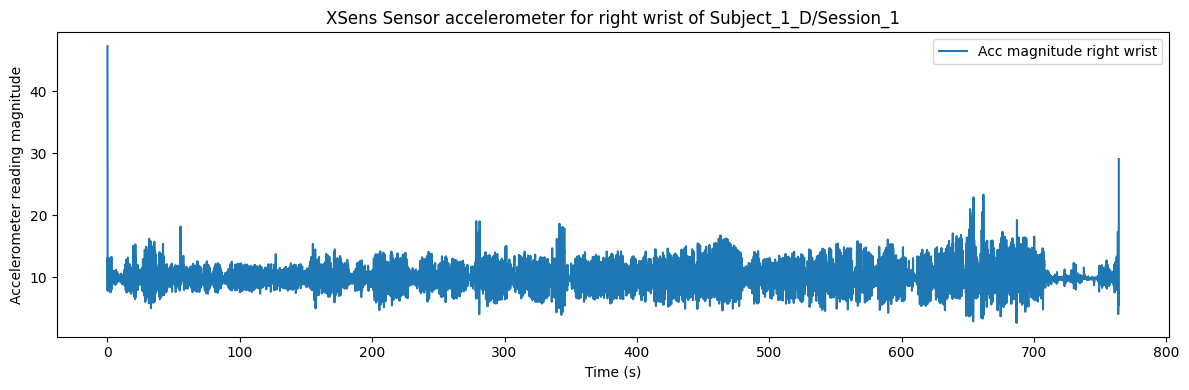

Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\XSens_trimmed
Processing data in C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_2\XSens_raw
   [!] XSensData_Rome_10B41721.txt: dropped frames detected! Diff steps found: [1. 2.]

Row counts match across sensors: False
PacketCounter ranges match across sensors: True
10B41704    : 46331 rows kept, 0.00s -> 772.17s
10B41706    : 46331 rows kept, 0.00s -> 772.17s
10B4170B    : 46331 rows kept, 0.00s -> 772.17s
10B4170C    : 46331 rows kept, 0.00s -> 772.17s
10B4170D    : 46331 rows kept, 0.00s -> 772.17s
10B4170E    : 46331 rows kept, 0.00s -> 772.17s
10B4170F    : 46331 rows kept, 0.00s -> 772.17s
10B41710    : 46331 rows kept, 0.00s -> 772.17s
10B41721    : 46331 rows kept, 0.00s -> 772.18s
10B41722    : 46331 rows kept, 0.00s -> 772.17s
10B4175D    : 46331 rows kept, 0.00s -> 772.17s
10B4175E    : 46331 rows kept, 0.00s -> 772.17s
10B4175F    : 46331 rows kept,

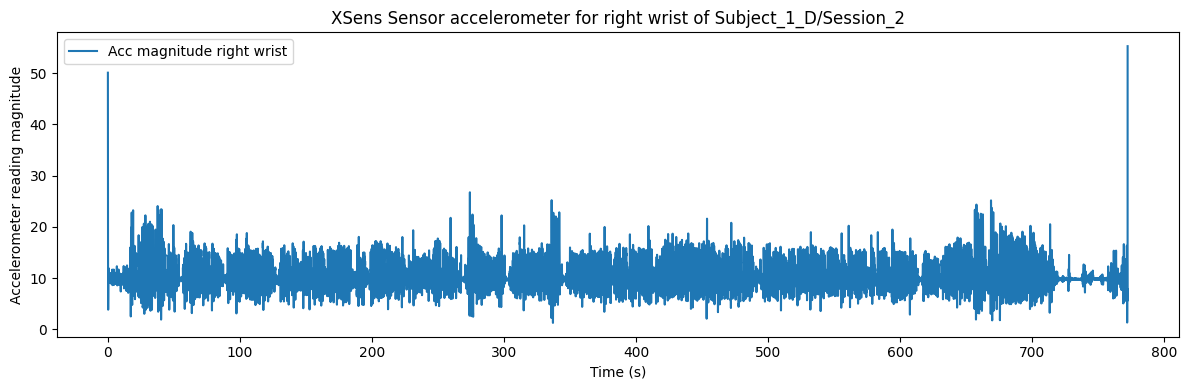

Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_2\XSens_trimmed
Processing data in C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_1\XSens_raw

Row counts match across sensors: True
PacketCounter ranges match across sensors: True
10B41704    : 49985 rows kept, 0.00s -> 833.07s
10B41706    : 49985 rows kept, 0.00s -> 833.07s
10B4170B    : 49985 rows kept, 0.00s -> 833.07s
10B4170C    : 49985 rows kept, 0.00s -> 833.07s
10B4170D    : 49985 rows kept, 0.00s -> 833.07s
10B4170E    : 49985 rows kept, 0.00s -> 833.07s
10B4170F    : 49985 rows kept, 0.00s -> 833.07s
10B41710    : 49985 rows kept, 0.00s -> 833.07s
10B41721    : 49985 rows kept, 0.00s -> 833.07s
10B41722    : 49985 rows kept, 0.00s -> 833.07s
10B4175D    : 49985 rows kept, 0.00s -> 833.07s
10B4175E    : 49985 rows kept, 0.00s -> 833.07s
10B4175F    : 49985 rows kept, 0.00s -> 833.07s
10B41760    : 49985 rows kept, 0.00s -> 833.07s
10B4178A    : 49985 ro

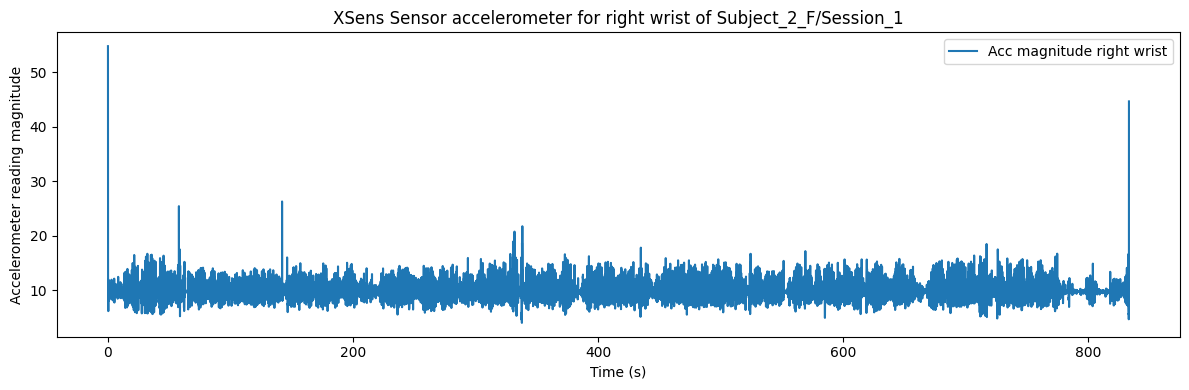

Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_1\XSens_trimmed
Processing data in C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_2\XSens_raw
   [!] XSensData_Rome_10B4175D.txt: dropped frames detected! Diff steps found: [1. 2.]

Row counts match across sensors: False
PacketCounter ranges match across sensors: True
10B41704    : 49718 rows kept, 0.00s -> 828.62s
10B41706    : 49718 rows kept, 0.00s -> 828.62s
10B4170B    : 49718 rows kept, 0.00s -> 828.62s
10B4170C    : 49718 rows kept, 0.00s -> 828.62s
10B4170D    : 49718 rows kept, 0.00s -> 828.62s
10B4170E    : 49718 rows kept, 0.00s -> 828.62s
10B4170F    : 49718 rows kept, 0.00s -> 828.62s
10B41710    : 49718 rows kept, 0.00s -> 828.62s
10B41721    : 49718 rows kept, 0.00s -> 828.62s
10B41722    : 49718 rows kept, 0.00s -> 828.62s
10B4175D    : 49718 rows kept, 0.00s -> 828.63s
10B4175E    : 49718 rows kept, 0.00s -> 828.62s
10B4175F    : 49718 rows kept,

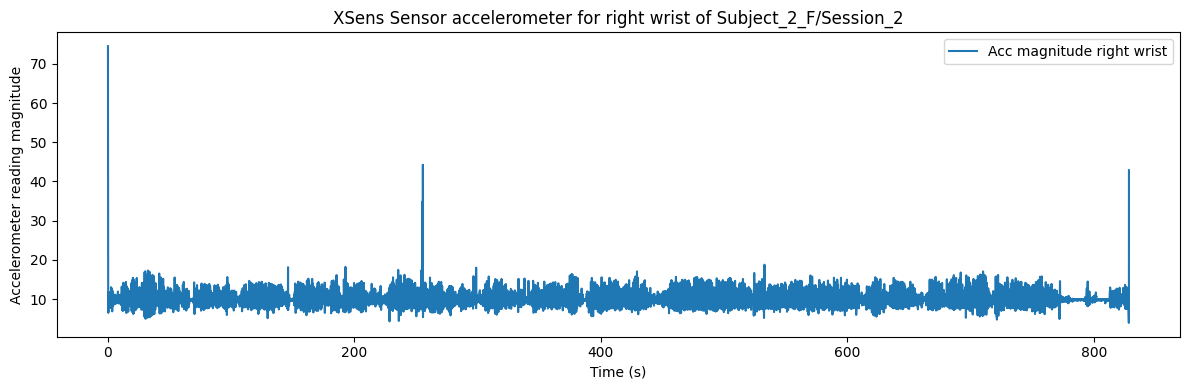

Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_2\XSens_trimmed
Processing data in C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_1\XSens_raw
   [!] XSensData_Rome_10B4170D.txt: dropped frames detected! Diff steps found: [1. 2.]

Row counts match across sensors: False
PacketCounter ranges match across sensors: True
10B41704    : 43186 rows kept, 0.00s -> 719.75s
10B41706    : 43186 rows kept, 0.00s -> 719.75s
10B4170B    : 43186 rows kept, 0.00s -> 719.75s
10B4170C    : 43186 rows kept, 0.00s -> 719.75s
10B4170D    : 43186 rows kept, 0.00s -> 719.77s
10B4170E    : 43186 rows kept, 0.00s -> 719.75s
10B4170F    : 43186 rows kept, 0.00s -> 719.75s
10B41710    : 43186 rows kept, 0.00s -> 719.75s
10B41721    : 43186 rows kept, 0.00s -> 719.75s
10B41722    : 43186 rows kept, 0.00s -> 719.75s
10B4175D    : 43186 rows kept, 0.00s -> 719.75s
10B4175E    : 43186 rows kept, 0.00s -> 719.75s
10B4175F    : 43186 rows kept,

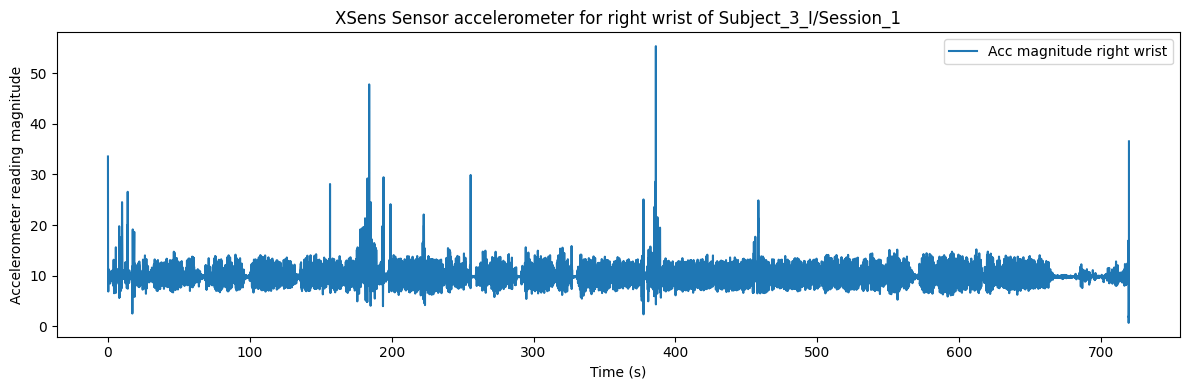

Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_1\XSens_trimmed
Processing data in C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_2\XSens_raw

Row counts match across sensors: True
PacketCounter ranges match across sensors: True
10B41704    : 43151 rows kept, 0.00s -> 719.17s
10B41706    : 43151 rows kept, 0.00s -> 719.17s
10B4170B    : 43151 rows kept, 0.00s -> 719.17s
10B4170C    : 43151 rows kept, 0.00s -> 719.17s
10B4170D    : 43151 rows kept, 0.00s -> 719.17s
10B4170E    : 43151 rows kept, 0.00s -> 719.17s
10B4170F    : 43151 rows kept, 0.00s -> 719.17s
10B41710    : 43151 rows kept, 0.00s -> 719.17s
10B41721    : 43151 rows kept, 0.00s -> 719.17s
10B41722    : 43151 rows kept, 0.00s -> 719.17s
10B4175D    : 43151 rows kept, 0.00s -> 719.17s
10B4175E    : 43151 rows kept, 0.00s -> 719.17s
10B4175F    : 43151 rows kept, 0.00s -> 719.17s
10B41760    : 43151 rows kept, 0.00s -> 719.17s
10B4178A    : 43151 ro

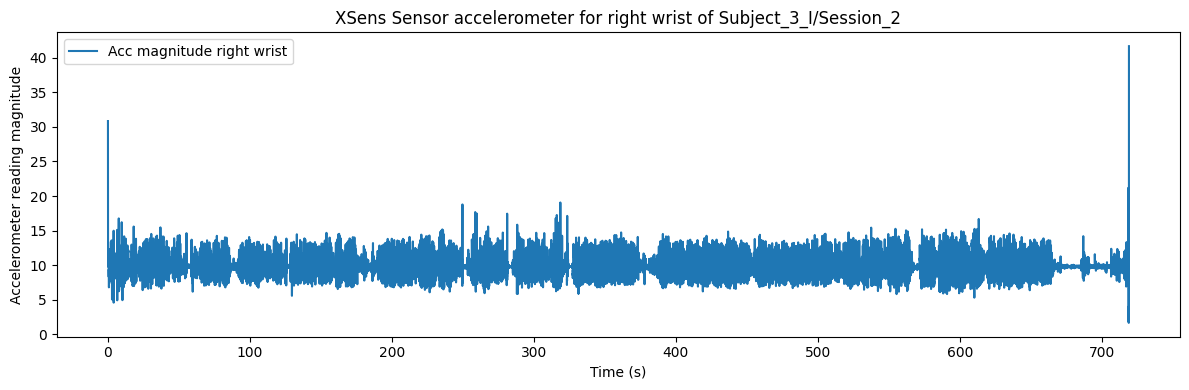

Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_2\XSens_trimmed


In [41]:
ses = ["Session_1", "Session_2"]
Data_Dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")

for folder in Data_Dir.iterdir():
    for session in ses:
        DATA_DIR = folder / session / "XSens_raw"
        FILE_PREFIX = "XSensData_Rome" + "_"
        print(f"Processing data in {DATA_DIR}")
        # Load the Sensor Logger data
        DATA_DIR_Sensor_logger = folder / session / os.path.join("Sensor_logger_recordings", "trimmed_60Hz")
        file_prefix = "trimmed_TotalAcceleration"
        sensor_logger_path = os.path.join(DATA_DIR_Sensor_logger, f"{file_prefix}.csv")
        sensor_logger_df = pd.read_csv(sensor_logger_path, delimiter=',', header=0)
        get_trimmed_dir(DATA_DIR, FILE_PREFIX,sensor_logger_df["time"][0])

In [5]:
def plot_acceleration_magnitude_with_checkpoints(dir_file, data_doc_dir, sensor_trimmed_dir, sensor_logger_recordings_trimmed_dir, step_logger_dir, xsens_file_prefix_right_wrist, step_logger_file_prefix, sensor_logger_file_prefix):
    for i in range(len(dir_file)):
        # Load the Xsens trimmed data for right and left wrist
        right_wrist_path = os.path.join(data_doc_dir, dir_file[i], sensor_trimmed_dir, f"{xsens_file_prefix_right_wrist}.csv")        
        right_wrist_df = pd.read_csv(right_wrist_path, delimiter=',', header=0)
        
        # Load the Step Logger data
        step_logger_path = os.path.join(data_doc_dir, dir_file[i], step_logger_dir, f"{step_logger_file_prefix}.csv")
        step_logger_df = pd.read_csv(step_logger_path, delimiter=',', header=0)
        
        # Load the Sensor Logger data
        sensor_logger_path = os.path.join(data_doc_dir, dir_file[i], sensor_logger_recordings_trimmed_dir, f"{sensor_logger_file_prefix}.csv")
        sensor_logger_df = pd.read_csv(sensor_logger_path, delimiter=',', header=0)

        # Calculate the acceleration magnitude
        acc_mag_right_wrist = np.sqrt(right_wrist_df["Acc_X"]**2 + right_wrist_df["Acc_Y"]**2 + right_wrist_df["Acc_Z"]**2)

        acc_mag_sensor_logger = np.sqrt(sensor_logger_df["x"]**2 + sensor_logger_df["y"]**2 + sensor_logger_df["z"]**2)

        plots_data = [
            ("XSens Right Wrist", right_wrist_df["Normalized_time_secs"], acc_mag_right_wrist),
            ("Sensor Logger Phone", sensor_logger_df["Normalized_time_secs"], acc_mag_sensor_logger),
        ]

        # 4. Generate 3 Graphs per Session
        for title_prefix, time_col, mag_signal in plots_data:
            plt.figure(figsize=(12, 4))
            plt.ticklabel_format(useOffset=False, style="plain")

            # Plot Accelerometer Signal
            plt.plot(time_col, mag_signal, label="Acc Magnitude", color="C0")

            # Loop over each checkpoint in the step logger DataFrame
            for idx, row in step_logger_df.iterrows():
                event_time = row["time_s"]
                checkpoint_label = str(row["Checkpoint"]).strip()

                # 1. Draw vertical event line
                line_label = "Sensor Logger Event" if idx == 0 else ""
                plt.axvline(
                    x=event_time,
                    color="red",
                    linestyle="--",
                    alpha=0.6,
                    linewidth=1.2,
                    label=line_label,
                )

            plt.xlabel("Time (s)")
            plt.ylabel("Acceleration ($m/s^2$)")
            plt.title(f"{title_prefix} - {dir_file[i]}")
            plt.legend(loc="upper right")
            plt.tight_layout()
            plt.show()

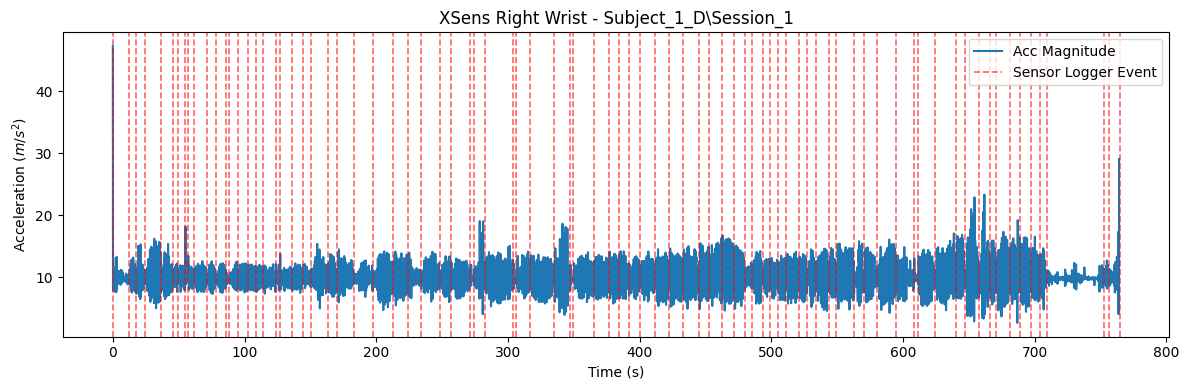

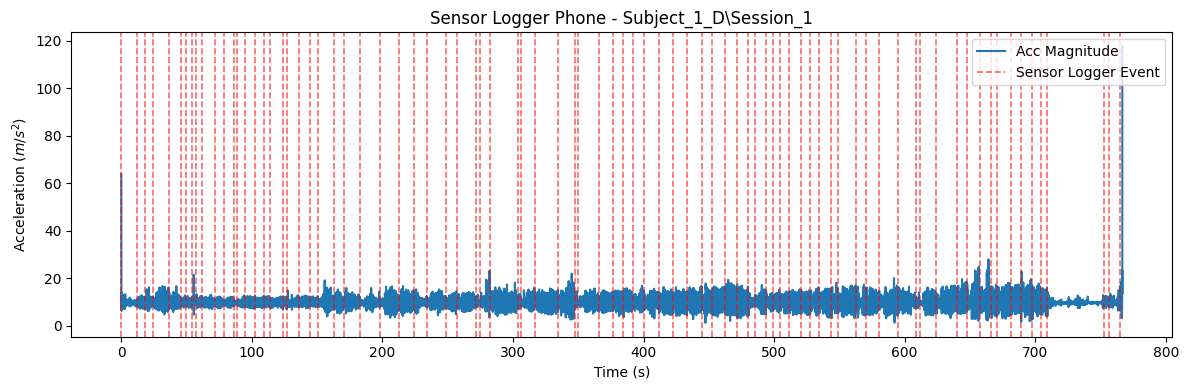

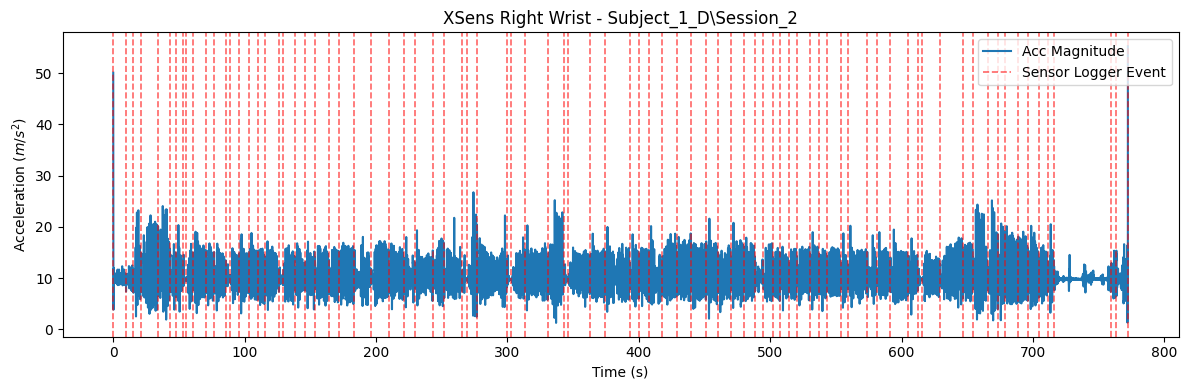

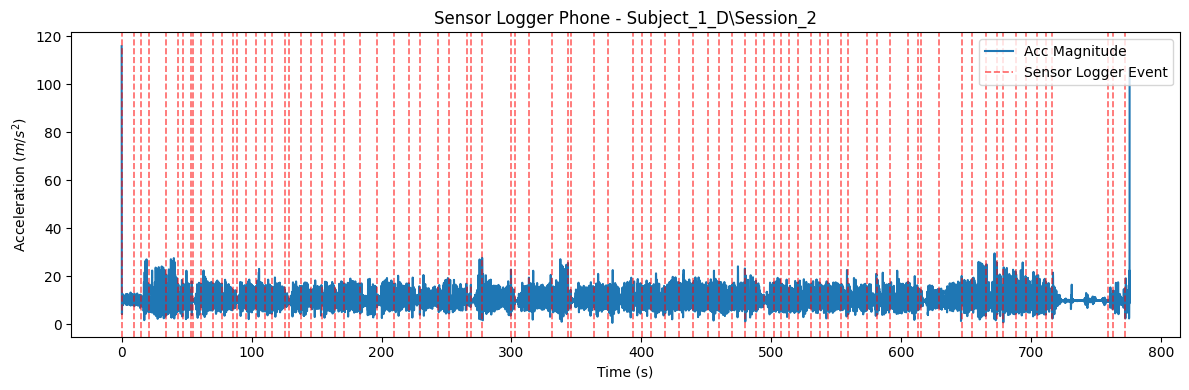

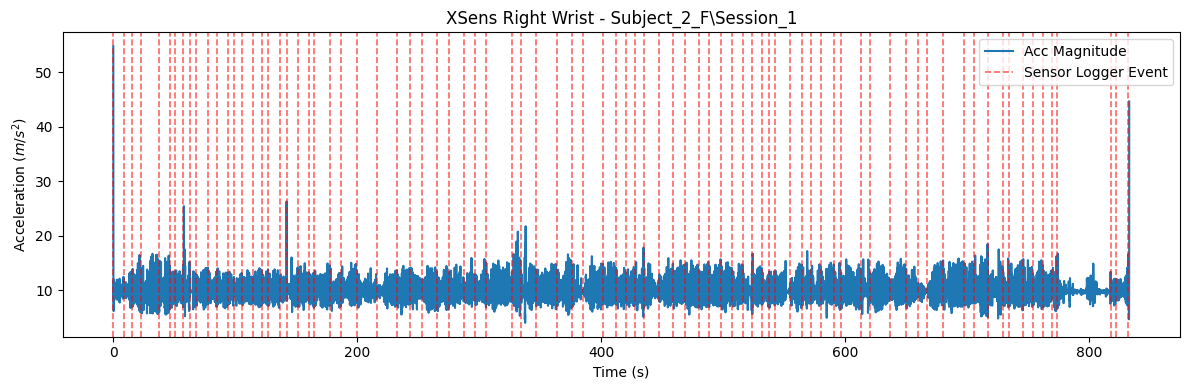

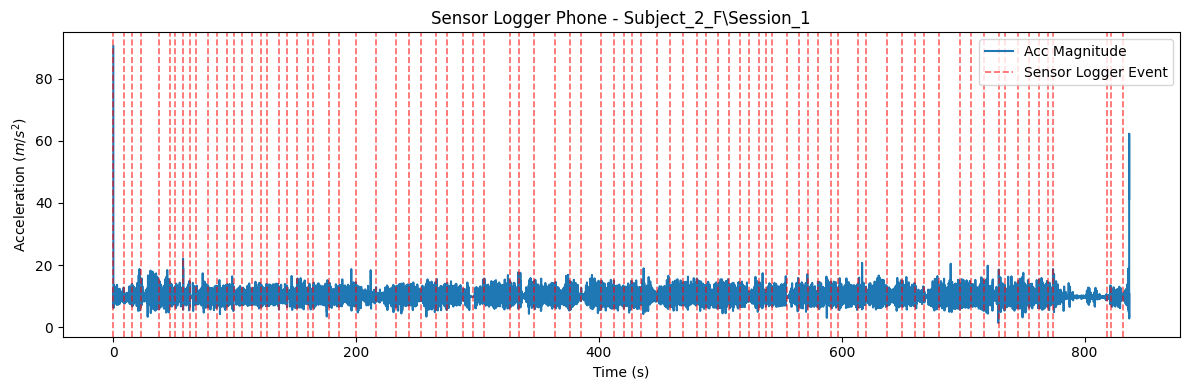

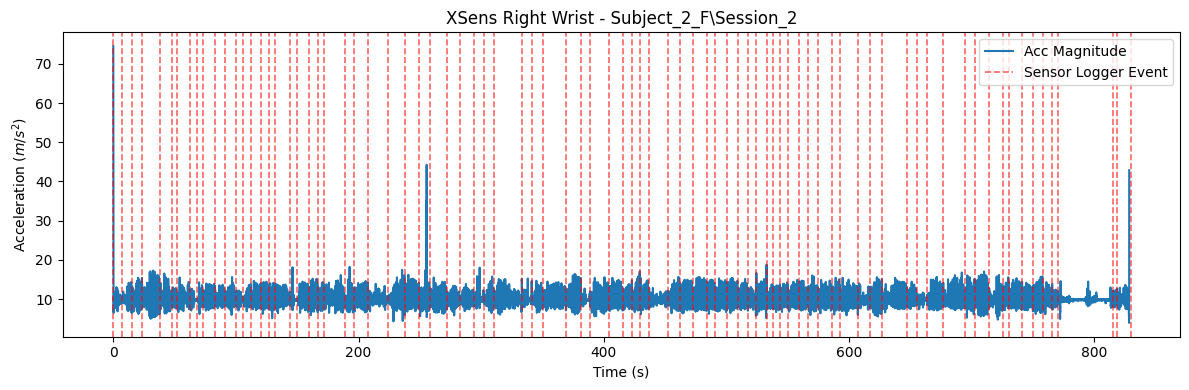

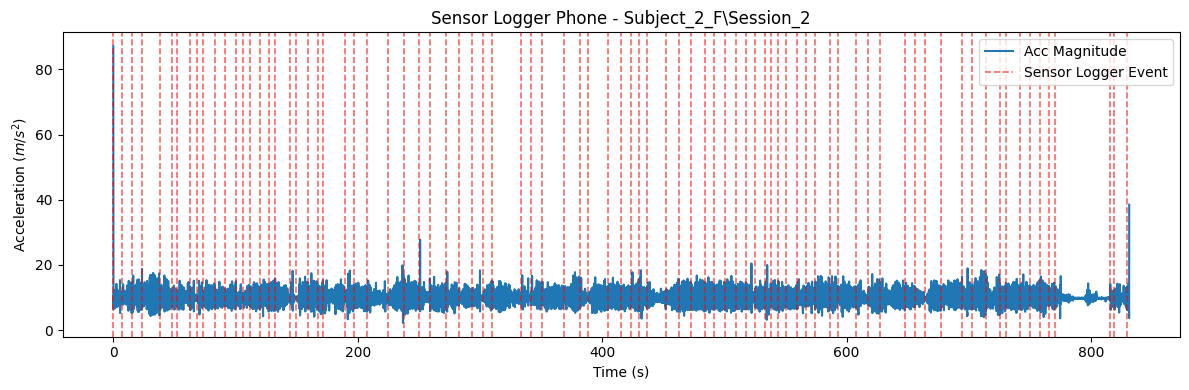

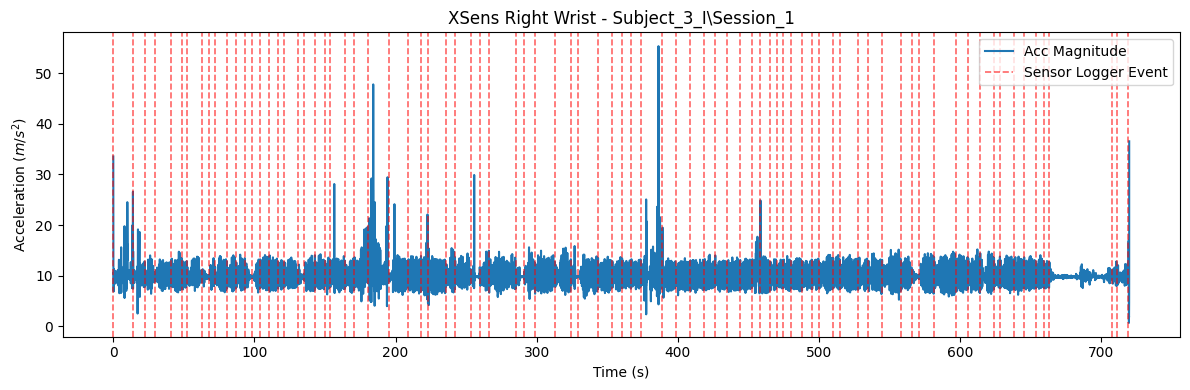

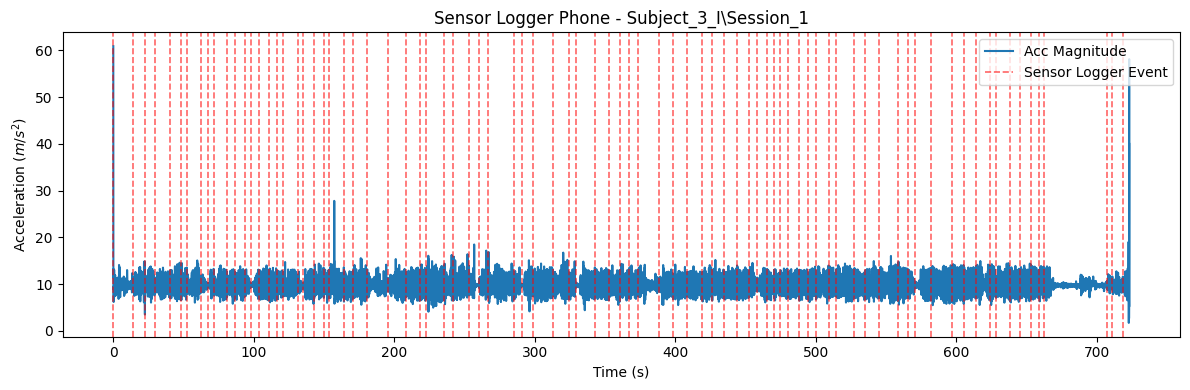

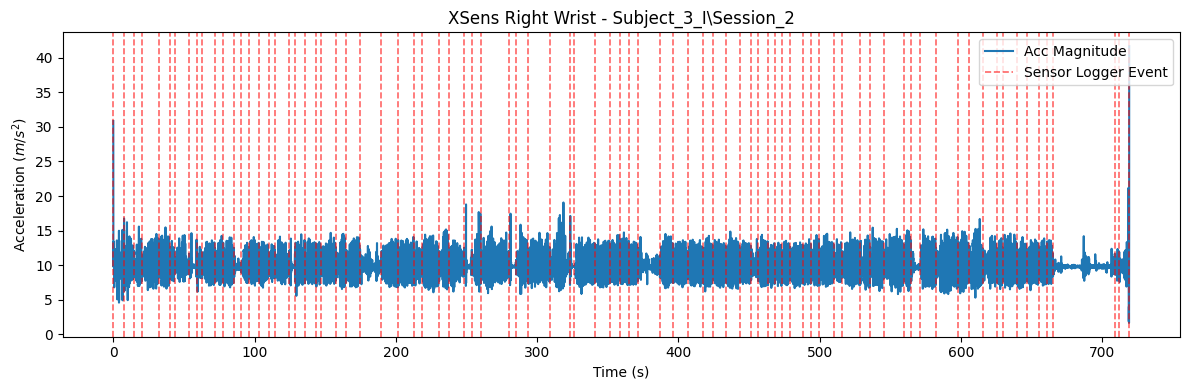

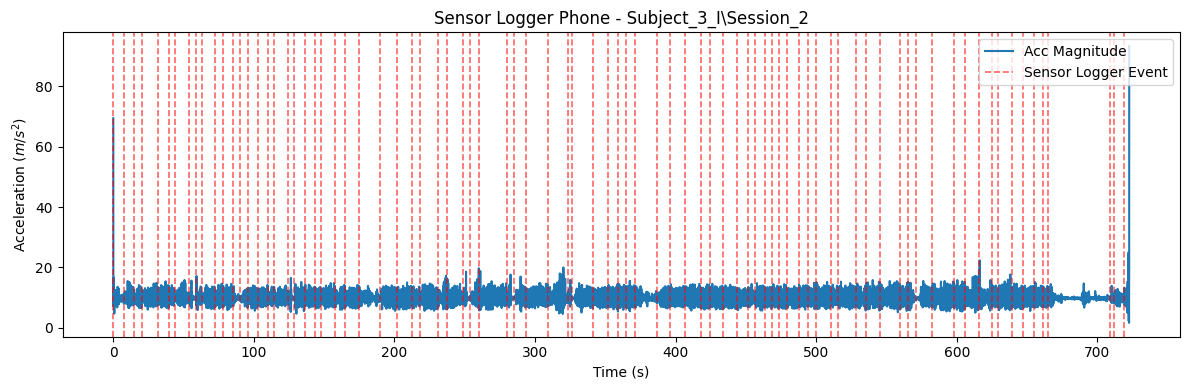

In [8]:
dir_file = [os.path.join("Subject_1_D", "Session_1"), os.path.join("Subject_1_D", "Session_2"), os.path.join("Subject_2_F", "Session_1"), os.path.join("Subject_2_F", "Session_2"), os.path.join("Subject_3_I", "Session_1"), os.path.join("Subject_3_I", "Session_2")]
data_doc_dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")

sensor_trimmed_dir = "XSens_trimmed"

sensor_logger_recordings_trimmed_dir = os.path.join("Sensor_logger_recordings", "trimmed_60Hz")

step_logger_dir = "Step_logger"

xsens_file_prefix_right_wrist = "trimmed_10B41710"

step_logger_file_prefix = "buttonsPressed"

sensor_logger_file_prefix = "trimmed_TotalAcceleration"

plot_acceleration_magnitude_with_checkpoints(dir_file, data_doc_dir, sensor_trimmed_dir, sensor_logger_recordings_trimmed_dir, step_logger_dir, xsens_file_prefix_right_wrist, step_logger_file_prefix, sensor_logger_file_prefix)